# 📊 Project 4: Income Prediction Using Categorical Data
Here we load the data from the folder which has been downloaded and uploaded with the code to the Git. Also here we load some important modules which wee need throughout this notebook. Also we fix a seed for the whole notebook just to be safe.


In [71]:
# Enable autoreloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd
import time

import random

SEED = 42

if SEED is not None:
    np.random.seed(SEED)
    random.seed(SEED)
    print(f"Seed: {SEED} set")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Seed: 42 set


The data gets loaded in its right format according to the guidelines which inlcude that the target variable needs to be formatted

$$
y =
\begin{cases}
1 & \text{if income } > \$50K \\
0 & \text{otherwise}
\end{cases}
$$.

Furthermore, one column gets dropped indefently as it will not be used within this task.


In [72]:
file_name = "adult.data"
column_names = column_names = [ #names of all columns from the data set
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "Class"
]
df = pd.read_csv(file_name, names= column_names,skipinitialspace=True)

target_variable_map = { # we map according to the task guidelines
    "<=50K": 0,
    ">50K": 1,
}

columns_to_be_dropped = [ # we drop the fnlwgt as it represents weights and we deem it as not neccessary within this task
    "fnlwgt"
]

df= df.drop(columns=columns_to_be_dropped)
df["Class"] = df["Class"].map(target_variable_map)
df

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Class
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


## Identify which categorical features are low- or high-cardinality

Text


## Analyze which variables have a meaningful order (e.g., education)

Text

## Implement and compare the Encoding strategies

All encoding strategies are implemented in the project library which has been created specifically for this project. In the following a short description will, however, a deeper insight will be given in the Latex-report.

### `Hot_One_Encoder` 

In [73]:
from projectlib.encoding import One_Hot_Encoder
help(One_Hot_Encoder)

Help on function One_Hot_Encoder in module projectlib.encoding:

One_Hot_Encoder(df, column_to_be_encoded, number_if_True=1, number_if_False=0, delete_old_column=False, drop_these_data_rows=[])
    takes a pandas dataframe and columns which need to be encoded and creates new column according to the columns categories.
       The rows then get marked wether the row has or has not the column property.
       outputs then a new edited copy of df.

    Args:
        df (pd.dataframe): just the dataset
        column_to_be_encoded (list): a list of column names form df which need to be encoded
        number_if_True (int, optional): number if the column property applies to the row. Defaults to 1.
        number_if_False (int, optional): number if the column property does not apply to the row. Defaults to 0.
        delete_old_column (bool, optional): Wether the columns form column_to_be_encoded are deleted or not. Defaults to False.
        drop_these_data_rows (list, optional): Drops all r

### `Ordinal_Encoder`

In [74]:
from projectlib.encoding import Ordinal_Encoder
help(Ordinal_Encoder)

Help on function Ordinal_Encoder in module projectlib.encoding:

Ordinal_Encoder(df, column_to_be_encoded, categories_order=[[]], starting_numbers=None, step_sizes=None, drop_unknown_data_rows=[])
    takes a pandas dataframe and columns which need to be encoded and creates transforms the columns accordingly to the other inputs.
       outputs then a new edited copy of df. Important: the old columns get overridden with the new values (in the copy)

    Args:
        df (pd.dataframe): just the dataset
        column_to_be_encoded (list): a list of column names from df which need to be encoded
        categories_order (list of list): the length of the outer list is the same as column_to_be_encoded, the inner list give the categories AND the order of these categories MUST be INCREASING. if a category is given as a list list itself, fe [cat1,cat2] they will be set equal
        starting_numbers (list of doubles, optional): list of numbers with the same length as column_to_be_encoded, each

### `Frequency_Encoder`

In [75]:
from projectlib.encoding import Frequency_Encoder
help(Frequency_Encoder)

Help on function Frequency_Encoder in module projectlib.encoding:

Frequency_Encoder(df, column_to_be_encoded, delete_old_column=False, drop_unknown_data_rows=[])
    takes a pandas dataframe and columns which need to be encoded and creates new column called "{oldcolumnname}_freq".
       The new column has then the frequency representation
       outputs then a new edited copy of df.

    Args:
        df (pd.dataframe): just the dataset
        column_to_be_encoded (list): a list of column names form df which need to be encoded
        delete_old_column (bool, optional): Wether the columns form column_to_be_encoded are deleted or not. Defaults to False.
        drop_unknown_data_rows (list, optional): Drops all rows which include the strings which are in this list. Defaults to empty list.



### `Target_Encoder` and `Target_Encoder_LC`
Within the Task it was asked to implement a leakage controlled (LC) way to conduct CV. Therefore, the `Target_Encoder_LC` is an extension of the `Target_Encoder` which was implemented first. Both differe in only one aspect. The `Target_Encoder_LC` allows two dataframe inputs. One is the dataframe that needs encoding and the second is giving the data. Thus, for the optional case $D_1 \cap D_2 = \empty$ for $D_1, D_2$ datasets, $D_1$ can be encoded with information from $D_2$, giving an independent encoding strategy.

In [76]:
from projectlib.encoding import Target_Encoder_LC,Target_Encoder
help(Target_Encoder)
help(Target_Encoder_LC)

Help on function Target_Encoder in module projectlib.encoding:

Target_Encoder(df, column_to_be_encoded, target_column_name, delete_old_column=False, drop_unknown_data_rows=[])
    takes a pandas dataframe and columns which need to be encoded and creates new column called "{oldcolumnname}_target".
       The new column has then the target representation
       outputs then a new edited copy of df.

    Args:
        df (pd.dataframe): just the dataset
        column_to_be_encoded (list): a list of column names form df which need to be encoded
        target_column_name (str): the column name of the target variable
        delete_old_column (bool, optional): Wether the columns form column_to_be_encoded are deleted or not. Defaults to False.
        drop_unknown_data_rows (list, optional): Drops all rows which include the strings which are in this list. Defaults to empty list.

Help on function Target_Encoder_LC in module projectlib.encoding:

Target_Encoder_LC(df_to_encode, df_for_targe

### `SmoothTarget_Encoder` and `SmoothTarget_Encoder_LC`
`SmoothTarget_Encoder` and `SmoothTarget_Encoder_LC` have the same background and motivation as the `Target_Encoder` and `Target_Encoder_LC`.

In [77]:
from projectlib.encoding import SmoothTarget_Encoder_LC,SmoothTarget_Encoder
help(SmoothTarget_Encoder)
help(SmoothTarget_Encoder_LC)

Help on function SmoothTarget_Encoder in module projectlib.encoding:

SmoothTarget_Encoder(df, column_to_be_encoded, target_column_name, alpha=1.0, delete_old_column=False, drop_unknown_data_rows=[])
    takes a pandas dataframe and columns which need to be encoded and creates new column called "{oldcolumnname}_smooth_target".
       The new column has then the smoothed target representation
       outputs then a new edited copy of df.

    Args:
        df (pd.dataframe): just the dataset
        column_to_be_encoded (list): a list of column names form df which need to be encoded
        target_column_name (str): the column name of the target variable
        alpha (double, optional): smoothing parameter from the formula. Defaults to 1.0.
        delete_old_column (bool, optional): Wether the columns form column_to_be_encoded are deleted or not. Defaults to False.
        drop_unknown_data_rows (list, optional): Drops all rows which include the strings which are in this list. Defaults

## Minimum: Handle missing values appropriately ✅ 

## ✅ Apply and compare at least two different encoding strategies 
In this part the following Requirements will be satisfied:

- Apply and compare at least two different encoding strategies: One-hot and at least one of: ordinal or target

- Use cross-validation to train and evaluate models

- Report: accuracy, precision, recall

- Use models: Logistic regression (without regularization) and linear SVM


In this part we compare all encoding strategies and also one costum dataset which uses the data encoding methods more strategically on each column (if its categorical).

For the setup we will load the models (ie Logistic regression and linear SVM) from the , however, the linear SVM is implemented with the target varibale having values in $\{-1,1\}$ which is not what the task guidlines require. Thus, instead mapping the values form $\{0,1\}$ to $\{-1,1\}$, we decided to copy the model from the courselib and adapt it here in the notebook accordingly.

In [78]:
import numpy as np
from courselib.models.base import TrainableModel
from courselib.models.glm import LogisticRegression

class LinearSVM(TrainableModel):

    def __init__(self, w, b, optimizer, C=10.):
        super().__init__(optimizer)
        self.w = np.array(w, dtype=float)
        self.b = np.array(b, dtype=float)
        self.C = C
    
    def loss_grad(self, X, y):
       # Compute raw model output
        output = self.decision_function(X)

        y = np.where(y == 0, -1, 1)

        # Identify margin violations: where 1 - y*h(x) > 0
        mask = (1 - y * output) > 0
        y_masked = y[mask]
        X_masked = X[mask]

        # Compute 
        if len(y_masked) > 0:
            grad_w = 2 * self.w - self.C * np.mean(y_masked[:, None] * X_masked, axis=0)
            grad_b = - self.C * np.mean(y_masked)
        else:
            grad_b = 0.0
            grad_w = 2 * self.w

        return {"w": grad_w, "b": grad_b}
    
    def decision_function(self, X):
        return X @ self.w + self.b
    
    def _get_params(self):
        return {"w": self.w, "b": self.b}

    def __call__(self, X):
        return np.where(self.decision_function(X) >= 0, 1, 0)


Also loading the optimizer we will use throughout this notebook.

In [79]:
from courselib.optimizers import GDOptimizer

optimizer = GDOptimizer(learning_rate=0.01)

### ✅ Minimum: accuracy, precision, recall
We will load all three methods here and then use them in each case model evaluation case appropriatly. Also we will need nomralization between values as in some cases there will be a huge difference in the absolute value of variables values.

In [80]:
from courselib.utils.metrics import binary_accuracy
from courselib.utils.normalization import standardize

from projectlib.metrics import binary_precision, binary_recall # from the own added library

### ✅ One-Hot vs Ordinal vs Frequency Encoding

❌ aS One-Hot Encoding is very slow with CV, do the following:
- apply One-Hot Encoding using the whole data set without and without penalty
- compare this strategy directy with Ordinal Encoding 
- use the Logistic regression and linear SVM

Here we load every necessary method for conducting the CV.

In [81]:
from courselib.utils.splits import k_fold_split
from projectlib.splits import data_to_numpy_transfomer, k_fold_split_dataframe

Here we define all variables necessary over all Encoding cases. Especially, the inputs of the One-Hot, Ordinal and Frequency Encoder are defined here

In [82]:
k = 4 #number of folds

#inputs of One-Hot Encoder
one_hot_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    #"native-country"    
]

#inputs of Ordinal Encoder
cols_to_order = ["education", "workclass", "relationship", "marital-status", "occupation", "race","sex", "native-country"]

categories_order = [
    ["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th", "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm", "Bachelors", "Masters", "Prof-school", "Doctorate"],
    ["Never-worked", "Without-pay", "Private", "State-gov", "Local-gov", "Self-emp-not-inc", "Federal-gov", "Self-emp-inc"],
    ["Not-in-family", "Unmarried", "Other-relative", "Own-child", ["Husband", "Wife"]],
    ["Never-married", "Separated", "Divorced", "Widowed", "Married-spouse-absent", ["Married-civ-spouse", "Married-AF-spouse"]],
    ["Priv-house-serv", "Other-service", "Handlers-cleaners", "Farming-fishing", "Machine-op-inspct", "Transport-moving", "Adm-clerical", "Craft-repair", "Sales", "Tech-support", "Protective-serv", "Prof-specialty", "Armed-Forces", "Exec-managerial"],
    ["White", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other", "Black"],
    ["Female", "Male"],
    ["Haiti", "Nicaragua", "Laos", "Honduras", "India", "Cambodia", "Philippines", "Vietnam", "Guatemala", "Iran", "El-Salvador", "Jamaica", "Ecuador", "Cuba", "Columbia", "Peru", "Thailand", "Dominican-Republic", "Yugoslavia", "Mexico", "China", "Trinadad&Tobago", "Hungary", "Poland", "Greece", "Portugal", "Japan", "Taiwan", "South", "Puerto-Rico", "Outlying-US(Guam-USVI-etc)", "Italy", "France", "England", "Scotland", "Germany", "Canada", "Hong", "Holand-Netherlands", "United-States", "Ireland"]
]

starting_numbers = [1, 1, 1, 1, 1, 1,1,1]

step_sizes = [1, 1, 1, 1, 1, 1,1,1]

#inputs Frequency Encoder
freq_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

Here we start cross validation like in the lecture

❌❌PAY ATTENTION WHAT TO DO WITH NATIVE COUNTRY also fill in time

In [83]:
from projectlib.encoding import One_Hot_Encoder

starttime = time.time()

df_encoded = One_Hot_Encoder(df.drop(columns=["native-country","education-num"]),column_to_be_encoded=one_hot_cols, delete_old_column = True) #########drop native country maybe not

endtime = time.time()

print(f"⏰ Time for One-Hot Encoding pre CV: {endtime-starttime} sek")

X, Y = data_to_numpy_transfomer(df_encoded,class_column_name='Class')
X_cv, Y_cv = k_fold_split(X,Y,k=k)

oneHot_acc_by_fold_logreg = []
oneHot_prec_by_fold_logreg = []
oneHot_rec_by_fold_logreg = []

oneHot_acc_by_fold_linsvm = []
oneHot_prec_by_fold_linsvm = []
oneHot_rec_by_fold_linsvm = []


for i in range(k):
    print(f"📁 Starting fold {i+1}")
    
    x_train = np.concatenate(X_cv[:i] + X_cv[i+1:])
    y_train = np.concatenate(Y_cv[:i] + Y_cv[i+1:])
    x_test = X_cv[i]
    y_test = Y_cv[i]
    
    train_mean = np.mean(x_train, axis=0) ###standardize function tries to divide by zero. fix: compute mean and std from x_train, replace zero standard deviations by 1, then standardize with those adjusted values
    train_std = np.std(x_train, axis=0)
    train_std[train_std == 0] = 1

    x_train = (x_train - train_mean) / train_std
    x_test = (x_test - train_mean) / train_std
    
    w = np.zeros(x_train.shape[1])
    b = 0
    
    starttime = time.time()
    
    model = LogisticRegression(w, b, optimizer)
    model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
    
    endtime = time.time()
    print(f"⏰ Time for Training LogisticRegression for Fold {i+1}: {endtime-starttime} sek")
    
    y_pred = model(x_test)
    
    oneHot_acc_by_fold_logreg.append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
    oneHot_prec_by_fold_logreg.append(binary_precision(y_pred,y_test))
    oneHot_rec_by_fold_logreg.append(binary_recall(y_pred,y_test))
    
    starttime = time.time()
    
    model = LinearSVM(w, b, optimizer)
    model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
    
    endtime = time.time()
    print(f"⏰ Time for Training LinearSVM for Fold {i+1}: {endtime-starttime} sek")
    
    y_pred = model(x_test)
    
    oneHot_acc_by_fold_linsvm.append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
    oneHot_prec_by_fold_linsvm.append(binary_precision(y_pred,y_test))
    oneHot_rec_by_fold_linsvm.append(binary_recall(y_pred,y_test))

⏰ Time for One-Hot Encoding pre CV: 0.1834120750427246 sek
📁 Starting fold 1
⏰ Time for Training LogisticRegression for Fold 1: 3.8075015544891357 sek
⏰ Time for Training LinearSVM for Fold 1: 5.506370544433594 sek
📁 Starting fold 2
⏰ Time for Training LogisticRegression for Fold 2: 3.9569928646087646 sek
⏰ Time for Training LinearSVM for Fold 2: 5.202189922332764 sek
📁 Starting fold 3
⏰ Time for Training LogisticRegression for Fold 3: 4.008233308792114 sek
⏰ Time for Training LinearSVM for Fold 3: 5.232351064682007 sek
📁 Starting fold 4
⏰ Time for Training LogisticRegression for Fold 4: 3.7776942253112793 sek
⏰ Time for Training LinearSVM for Fold 4: 5.172548770904541 sek


Here we start the CV for the Ordinal Case

In [84]:
from projectlib.encoding import Ordinal_Encoder, drop_rows



starttime =time.time()

df_encoded = Ordinal_Encoder(
    drop_rows(df,["?"]),
    column_to_be_encoded=cols_to_order,
    categories_order=categories_order,
    starting_numbers=starting_numbers,
    step_sizes=step_sizes
)

endtime = time.time()
print(f"⏰ Time for Ordinal Encoding pre CV: {endtime-starttime} sek")

X, Y = data_to_numpy_transfomer(df_encoded,class_column_name='Class')
X_cv, Y_cv = k_fold_split(X,Y,k=k)

ordinal_acc_by_fold_logreg = []
ordinal_prec_by_fold_logreg = []
ordinal_rec_by_fold_logreg = []

ordinal_acc_by_fold_linsvm = []
ordinal_prec_by_fold_linsvm = []
ordinal_rec_by_fold_linsvm = []


for i in range(k):
    
    print(f"📁 Starting fold {i+1}")
    
    x_train = np.concatenate(X_cv[:i] + X_cv[i+1:])
    y_train = np.concatenate(Y_cv[:i] + Y_cv[i+1:])
    x_test = X_cv[i]
    y_test = Y_cv[i]
    
    train_mean = np.mean(x_train, axis=0)
    train_std = np.std(x_train, axis=0)
    train_std[train_std == 0] = 1

    x_train = (x_train - train_mean) / train_std  ###standardize function tries to divide by zero. fix: compute mean and std from x_train, replace zero standard deviations by 1, then standardize with those adjusted values
    x_test = (x_test - train_mean) / train_std
    
    w = np.zeros(x_train.shape[1])
    b = 0
    
    starttime =time.time()
    
    model = LogisticRegression(w, b, optimizer)
    model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
    
    endtime = time.time()
    print(f"⏰ Time for Training LogisticRegression for Fold {i+1}: {endtime-starttime} sek")
    
    y_pred = model(x_test)
    
    ordinal_acc_by_fold_logreg.append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
    ordinal_prec_by_fold_logreg.append(binary_precision(y_pred,y_test))
    ordinal_rec_by_fold_logreg.append(binary_recall(y_pred,y_test))
    
    starttime = time.time()
    
    model = LinearSVM(w, b, optimizer)
    model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
    
    endtime = time.time()
    print(f"⏰ Time for Training LinearSVM for Fold {i+1}: {endtime-starttime} sek")
    
    y_pred = model(x_test)
    
    ordinal_acc_by_fold_linsvm.append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
    ordinal_prec_by_fold_linsvm.append(binary_precision(y_pred,y_test))
    ordinal_rec_by_fold_linsvm.append(binary_recall(y_pred,y_test))

2399 out of 32561 were deleted, ie.92.63229016307852% still remain 
⏰ Time for Ordinal Encoding pre CV: 0.06263113021850586 sek
📁 Starting fold 1
⏰ Time for Training LogisticRegression for Fold 1: 0.8159334659576416 sek
⏰ Time for Training LinearSVM for Fold 1: 1.18674635887146 sek
📁 Starting fold 2
⏰ Time for Training LogisticRegression for Fold 2: 0.9487655162811279 sek
⏰ Time for Training LinearSVM for Fold 2: 1.3767156600952148 sek
📁 Starting fold 3
⏰ Time for Training LogisticRegression for Fold 3: 0.9501726627349854 sek
⏰ Time for Training LinearSVM for Fold 3: 1.4763715267181396 sek
📁 Starting fold 4
⏰ Time for Training LogisticRegression for Fold 4: 1.1194541454315186 sek
⏰ Time for Training LinearSVM for Fold 4: 1.5841023921966553 sek


In [85]:
from projectlib.encoding import Frequency_Encoder, drop_rows

drop_col = ["education-num"]

df_clean = drop_rows(df,["?"]).drop(columns=drop_col)
df_cv = k_fold_split_dataframe(df_clean,k=k)

frequency_acc_by_fold_logreg = []
frequency_prec_by_fold_logreg = []
frequency_rec_by_fold_logreg = []

frequency_acc_by_fold_linsvm = []
frequency_prec_by_fold_linsvm = []
frequency_rec_by_fold_linsvm = []

for i in range(k):
    print(f"📁 Starting fold {i+1}")
    
    df_train = pd.concat(df_cv[:i] + df_cv[i+1:]).reset_index(drop=True)
    df_test = df_cv[i].reset_index(drop=True)
    
    starttime = time.time()
    
    df_train = Frequency_Encoder(df_train,column_to_be_encoded=freq_cols, delete_old_column = True)
    df_test = Frequency_Encoder(df_test,column_to_be_encoded=freq_cols, delete_old_column = True)
    
    endtime = time.time()
    print(f"⏰ Time for Frequency Encoding for Fold {i+1}: {endtime-starttime} sek")
    
    x_train, y_train = data_to_numpy_transfomer(df_train,class_column_name='Class')
    x_test, y_test = data_to_numpy_transfomer(df_test,class_column_name='Class')
    
    train_mean = np.mean(x_train, axis=0)
    train_std = np.std(x_train, axis=0)
    train_std[train_std == 0] = 1

    x_train = (x_train - train_mean) / train_std
    x_test = (x_test - train_mean) / train_std
    
    w = np.zeros(x_train.shape[1])
    b = 0
    
    starttime = time.time()
    
    model = LogisticRegression(w, b, optimizer)
    model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
    
    endtime = time.time()
    print(f"⏰ Time for Training LogisticRegression for Fold {i+1}: {endtime-starttime} sek")
    
    y_pred = model(x_test)
    
    frequency_acc_by_fold_logreg.append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
    frequency_prec_by_fold_logreg.append(binary_precision(y_pred,y_test))
    frequency_rec_by_fold_logreg.append(binary_recall(y_pred,y_test))
    
    starttime = time.time()
    
    model = LinearSVM(w, b, optimizer)
    model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
    
    endtime = time.time()
    print(f"⏰ Time for Training LinearSVM for Fold {i+1}: {endtime-starttime} sek")
    
    y_pred = model(x_test)
    
    frequency_acc_by_fold_linsvm.append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
    frequency_prec_by_fold_linsvm.append(binary_precision(y_pred,y_test))
    frequency_rec_by_fold_linsvm.append(binary_recall(y_pred,y_test))

2399 out of 32561 were deleted, ie.92.63229016307852% still remain 
📁 Starting fold 1
⏰ Time for Frequency Encoding for Fold 1: 0.03128218650817871 sek
⏰ Time for Training LogisticRegression for Fold 1: 0.8187527656555176 sek
⏰ Time for Training LinearSVM for Fold 1: 1.3083484172821045 sek
📁 Starting fold 2
⏰ Time for Frequency Encoding for Fold 2: 0.03801441192626953 sek
⏰ Time for Training LogisticRegression for Fold 2: 0.8317837715148926 sek
⏰ Time for Training LinearSVM for Fold 2: 1.292055606842041 sek
📁 Starting fold 3
⏰ Time for Frequency Encoding for Fold 3: 0.030057191848754883 sek
⏰ Time for Training LogisticRegression for Fold 3: 0.894115686416626 sek
⏰ Time for Training LinearSVM for Fold 3: 1.274479627609253 sek
📁 Starting fold 4
⏰ Time for Frequency Encoding for Fold 4: 0.029025793075561523 sek
⏰ Time for Training LogisticRegression for Fold 4: 0.8273069858551025 sek
⏰ Time for Training LinearSVM for Fold 4: 1.300966739654541 sek


Now we plot

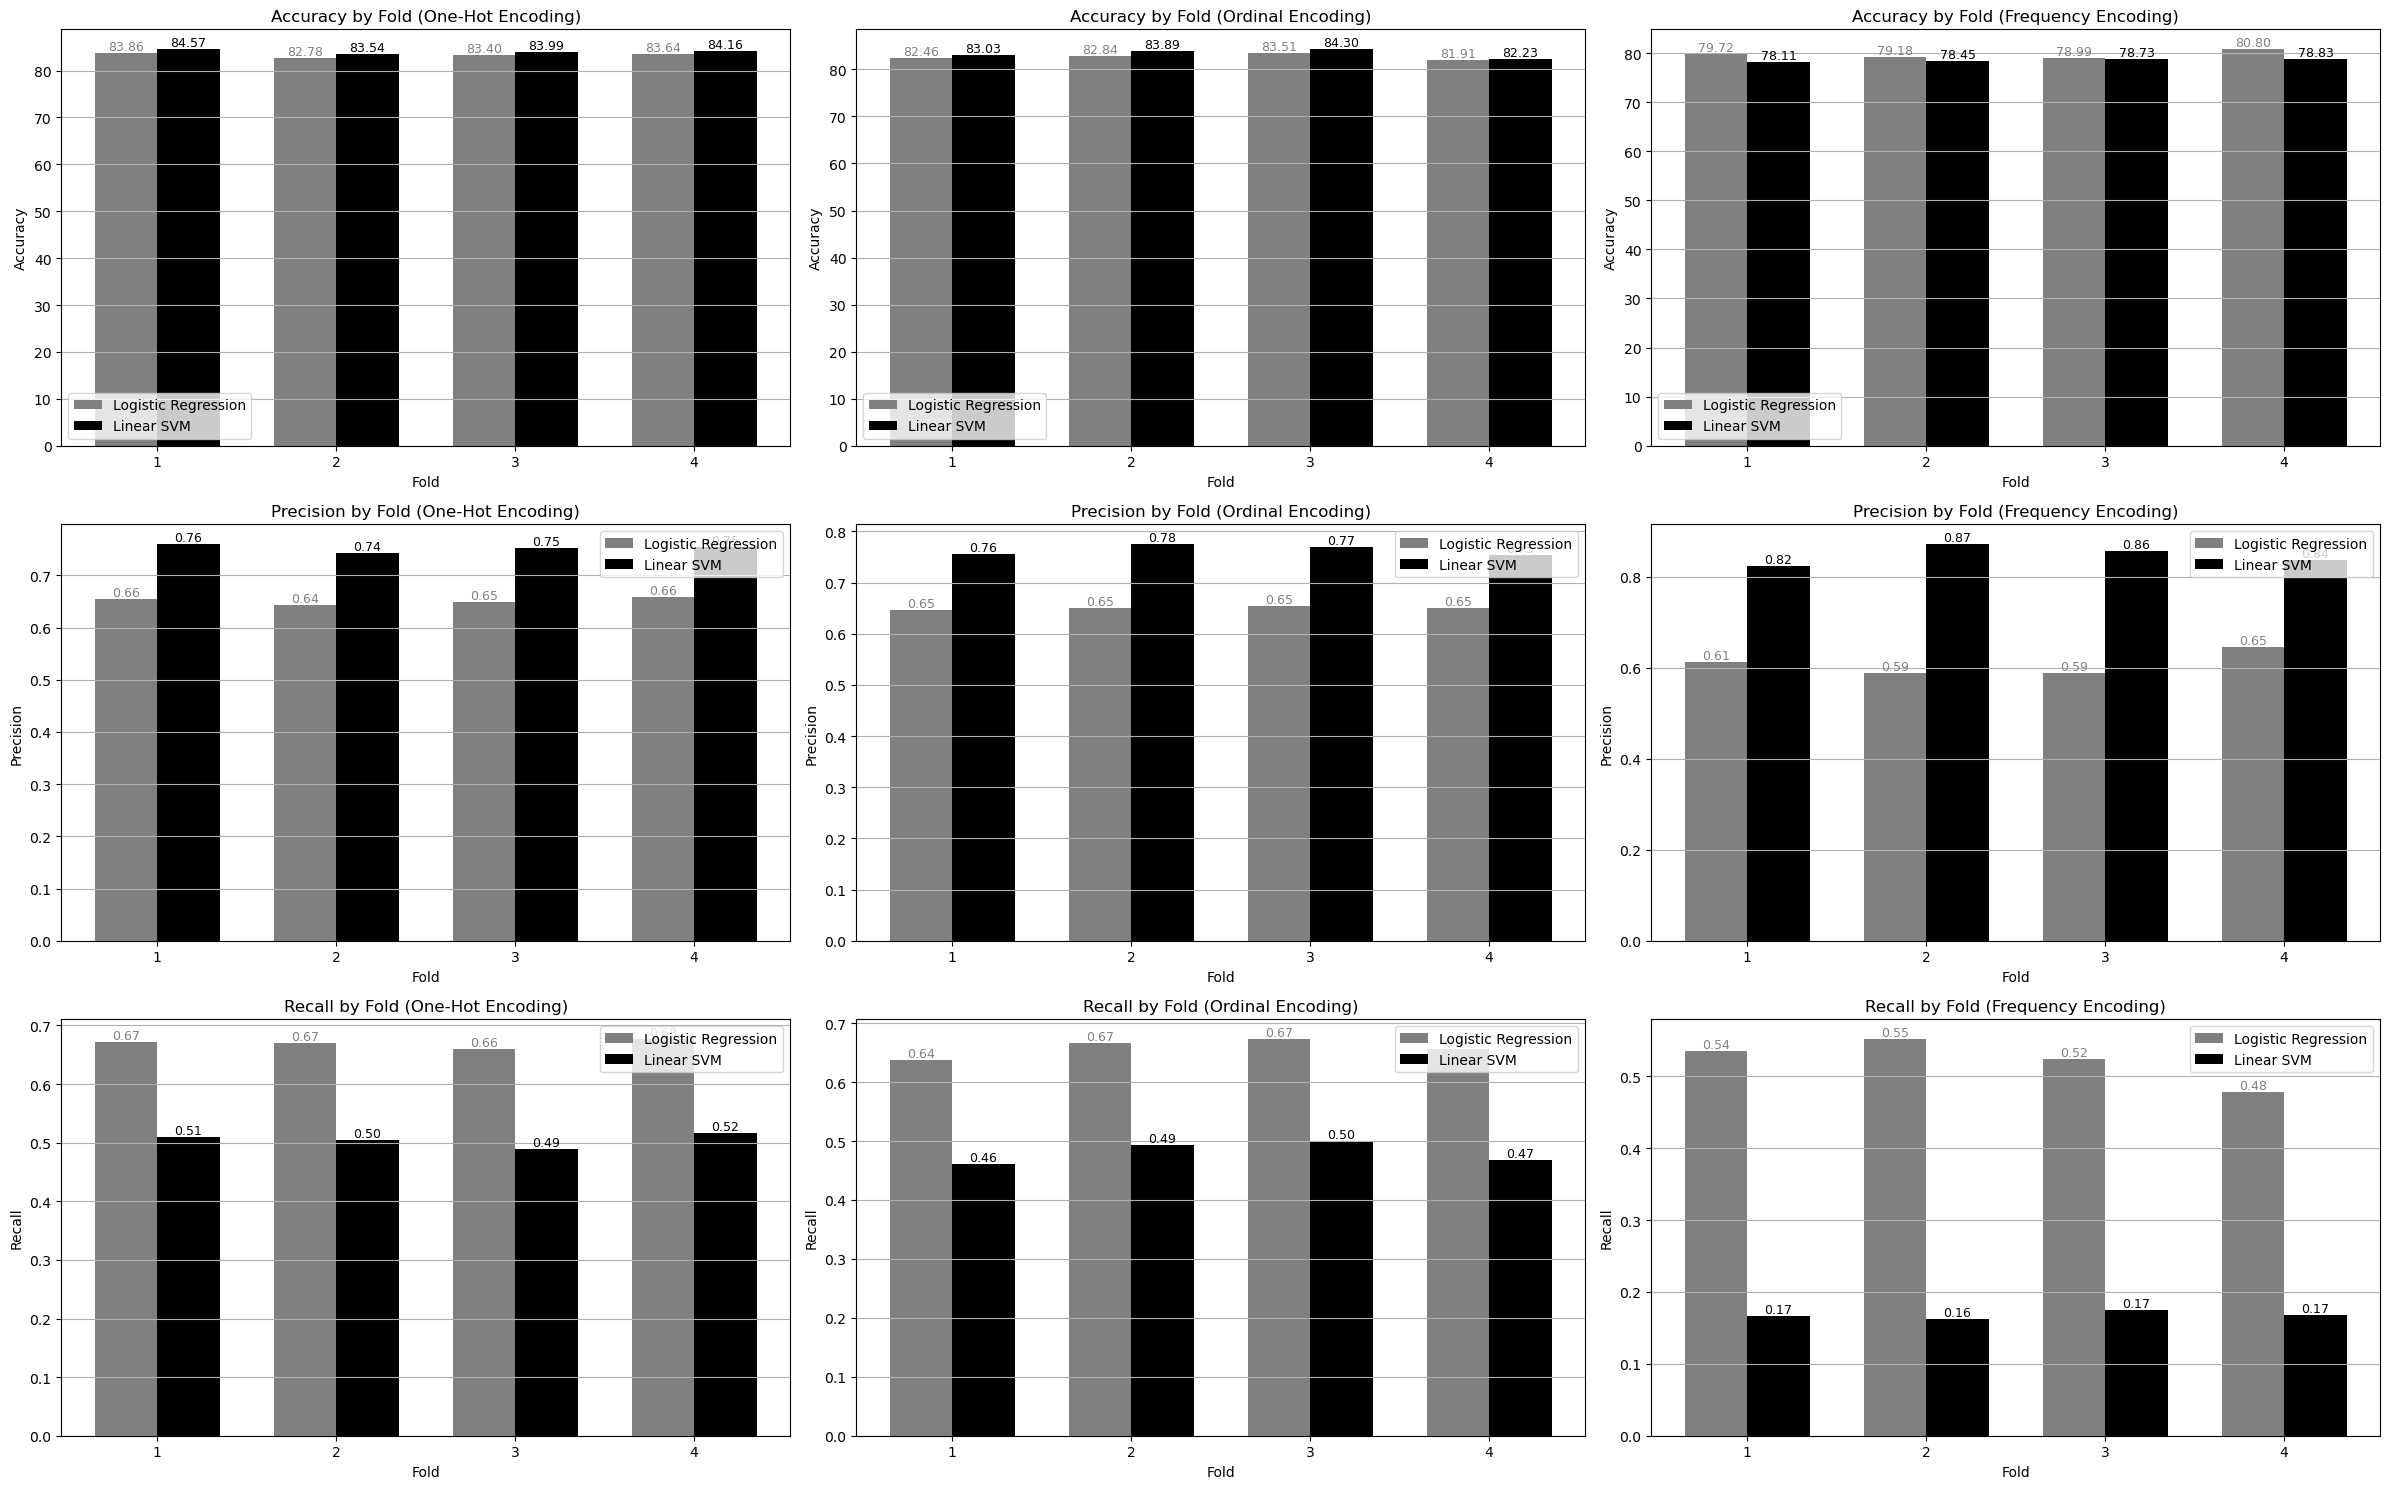

In [86]:
folds = np.arange(1, k + 1)
bar_width = 0.35

metric_data = [
    ("Accuracy",  oneHot_acc_by_fold_logreg, oneHot_acc_by_fold_linsvm, ordinal_acc_by_fold_logreg, ordinal_acc_by_fold_linsvm, frequency_acc_by_fold_logreg, frequency_acc_by_fold_linsvm),
    ("Precision", oneHot_prec_by_fold_logreg, oneHot_prec_by_fold_linsvm, ordinal_prec_by_fold_logreg, ordinal_prec_by_fold_linsvm, frequency_prec_by_fold_logreg, frequency_prec_by_fold_linsvm),
    ("Recall", oneHot_rec_by_fold_logreg, oneHot_rec_by_fold_linsvm, ordinal_rec_by_fold_logreg, ordinal_rec_by_fold_linsvm, frequency_rec_by_fold_logreg, frequency_rec_by_fold_linsvm)
]

fig, axes = plt.subplots(3, 3, figsize=(24, 15))

for row, (metric_name, onehot_logreg, onehot_linsvm, ordinal_logreg, ordinal_linsvm, frequency_logreg, frequency_linsvm) in enumerate(metric_data):
    
    ax = axes[row, 0]
    bars1 = ax.bar(folds - bar_width/2, onehot_logreg, width=bar_width, label="Logistic Regression", color="gray")
    bars2 = ax.bar(folds + bar_width/2, onehot_linsvm, width=bar_width, label="Linear SVM", color="black")
    
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}",
                ha='center', va='bottom', color=bar.get_facecolor(), fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}",
                ha='center', va='bottom', color=bar.get_facecolor(), fontsize=9)
    
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} by Fold (One-Hot Encoding)")
    ax.set_xticks(folds)
    ax.grid(axis='y')
    ax.legend()

    ax = axes[row, 1]
    bars1 = ax.bar(folds - bar_width/2, ordinal_logreg, width=bar_width, label="Logistic Regression", color="gray")
    bars2 = ax.bar(folds + bar_width/2, ordinal_linsvm, width=bar_width, label="Linear SVM", color="black")
    
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}",
                ha='center', va='bottom', color=bar.get_facecolor(), fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}",
                ha='center', va='bottom', color=bar.get_facecolor(), fontsize=9)
    
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} by Fold (Ordinal Encoding)")
    ax.set_xticks(folds)
    ax.grid(axis='y')
    ax.legend()

    ax = axes[row, 2]
    bars1 = ax.bar(folds - bar_width/2, frequency_logreg, width=bar_width, label="Logistic Regression", color="gray")
    bars2 = ax.bar(folds + bar_width/2, frequency_linsvm, width=bar_width, label="Linear SVM", color="black")
    
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}",
                ha='center', va='bottom', color=bar.get_facecolor(), fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}",
                ha='center', va='bottom', color=bar.get_facecolor(), fontsize=9)
    
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} by Fold (Frequency Encoding)")
    ax.set_xticks(folds)
    ax.grid(axis='y')
    ax.legend()

plt.tight_layout()
plt.show()

The figures above give use some good impression but now lets compare the each encoding method and model numerically with each other

In [87]:
for row, (metric_name, onehot_logreg, onehot_linsvm, ordinal_logreg, ordinal_linsvm, frequency_logreg, frequency_linsvm) in enumerate(metric_data):
    
    print("----------------------------------------------------------------------------")
    print(f"With respect to metric {metric_name}, the best evaluation results are:") 
    print("----------------------------------------------------------------------------")
    
    
    
    print("🌶️ One-Hot:")
    
    best_list = onehot_linsvm
    best_model= "LinearSVM"
    if np.max(onehot_logreg) > np.max(onehot_linsvm):
        best_list = onehot_logreg
        best_model ="LogisticRegression"
        
    elif np.max(onehot_logreg) == np.max(onehot_linsvm):
        best_model ="LogisticRegression and LinearSVM"
    
    print(f"Model {best_model} performed with {np.max(best_list)} at its best in fold {np.argmax(best_list)+1}")
    
    encoding_Max =("One-Hot", np.max(best_list),best_model)
    
    print("⏫ Ordinal:")
    
    best_list = ordinal_linsvm
    best_model= "LinearSVM"
    if np.max(ordinal_logreg) > np.max(ordinal_linsvm):
        best_list = ordinal_logreg
        best_model ="LogisticRegression"
        
    elif np.max(ordinal_logreg) == np.max(ordinal_linsvm):
        best_model ="LogisticRegression and LinearSVM"
    
    print(f"Model {best_model} performed with {np.max(best_list)} at its best in fold {np.argmax(best_list)+1}")
    
    if encoding_Max[1] < np.max(best_list):
        encoding_Max =("Ordinal", np.max(best_list),best_model)
    
    print("🔊 Frequency:")
    
    best_list = frequency_linsvm
    best_model= "LinearSVM"
    if np.max(frequency_logreg) > np.max(frequency_linsvm):
        best_list = frequency_logreg
        best_model ="LogisticRegression"
        
    elif np.max(frequency_logreg) == np.max(frequency_linsvm):
        best_model ="LogisticRegression and LinearSVM"
    
    print(f"Model {best_model} performed with {np.max(best_list)} at its best in fold {np.argmax(best_list)+1}")
    
    if encoding_Max[1] < np.max(best_list):
        encoding_Max =("Frequency", np.max(best_list),best_model)
    
    print(f"->> 🦾If only the best performence wrt {metric_name} is being considered, the best Encoding strategy is {encoding_Max[0]} ")

----------------------------------------------------------------------------
With respect to metric Accuracy, the best evaluation results are:
----------------------------------------------------------------------------
🌶️ One-Hot:
Model LinearSVM performed with 84.57191991155878 at its best in fold 1
⏫ Ordinal:
Model LinearSVM performed with 84.29708222811672 at its best in fold 3
🔊 Frequency:
Model LogisticRegression performed with 80.79575596816976 at its best in fold 4
->> 🦾If only the best performence wrt Accuracy is being considered, the best Encoding strategy is One-Hot 
----------------------------------------------------------------------------
With respect to metric Precision, the best evaluation results are:
----------------------------------------------------------------------------
🌶️ One-Hot:
Model LinearSVM performed with 0.7598760650658405 at its best in fold 1
⏫ Ordinal:
Model LinearSVM performed with 0.7750631844987363 at its best in fold 2
🔊 Frequency:
Model LinearSV

### ✅ Compare One-Hot vs Frequency vs Ordinal Encoding

text

## 🚀✅  Target Encoding vs Smooth Target Encoding with Leakage Control 

In this part the following Requirements will be satisfied:

- Use smoothed target encoding

- Implement leakage control for target encoding using cross-validation: Encode each fold using target statistics from other folds (not including the target of the encoded point)

- Apply Lasso regression to compare sparsity across encodings

- Use models: Logistic regression (with regularization)

Here we implement leakage control for target encoding using cross-validation, ie we encode each fold using target statistics from other folds (not including the target of the encoded point).

It is the following to note: oringally the idea was to use `k_fold_split` as in the lecture about regularization. However, as this method was developed for numpy input/output and our encoding methods were written to handle mainly dataframes we decided to implement a new method called `k_fold_split_dataframe` which essentially does the same as `k_fold_split`, however, it hanldes dataframe inputs/outputs. This allows us to use the encoding methods within the $k$-fold loops controlling leakage.

To still honor the original layout from the regularization/cross validation lecture we implemented a method called ` data_to_numpy_transfomer` which is just uses the `train_test_split`-method from the courselib and gives us back the respective `X` and `Y` from a given dataframe.

Here we set the parameters. 
For reference 
- `k` is the number of folds.
- `target_encoding_cols` is a list of the columns that will be encoded using the Target Encoder
- `penalty_functions` is a list of regularization term types.
- `lam` is a list of regularization hyperparameter.

In [88]:
k = 3

target_encoding_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

penalty_functions = ["ridge", "lasso"]
lam =[0.0,0.001,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,1.]

Here we nearly follow the steps taken in the regularization/cross validation lecture.

Here is total Leakage control for the normal Target Encoding

In [89]:
from projectlib.splits import k_fold_split_dataframe, data_to_numpy_transfomer
from projectlib.encoding import Target_Encoder_LC

df_cv = k_fold_split_dataframe(df,k=k)

targ_acc_by_fold = {penalty: [] for penalty in penalty_functions}
targ_prec_by_fold = {penalty: [] for penalty in penalty_functions}
targ_rec_by_fold = {penalty: [] for penalty in penalty_functions}

for i in range(k):
    print(f"📁 Starting fold {i+1}")
    
    starttime = time.time()
    
    df_train_raw = pd.concat(df_cv[:i] + df_cv[i+1:]).reset_index(drop=True)
    df_test_raw = df_cv[i].reset_index(drop=True)
    
    df_train_cv_inner = k_fold_split_dataframe(df_train_raw,k=k)
    df_train_encoded_folds = []
    
    for j in range(len(df_train_cv_inner)):
        df_train_inner_raw = pd.concat(df_train_cv_inner[:j] + df_train_cv_inner[j+1:]).reset_index(drop=True)
        df_test_inner_raw = df_train_cv_inner[j].reset_index(drop=True)
        
        df_test_inner = Target_Encoder_LC(df_test_inner_raw,df_train_inner_raw,column_to_be_encoded=target_encoding_cols,target_column_name="Class", delete_old_column = True)
        df_train_encoded_folds.append(df_test_inner)
    
    df_train = pd.concat(df_train_encoded_folds).reset_index(drop=True)
    df_test = Target_Encoder_LC(df_test_raw,df_train_raw,column_to_be_encoded=target_encoding_cols,target_column_name="Class", delete_old_column = True)
    
    endtime = time.time()
    print(f"⏰ Time for Target Encoding with Leakage Control: {endtime-starttime} sek")
    
    x_train, y_train = data_to_numpy_transfomer(df_train,class_column_name='Class')
    x_test, y_test = data_to_numpy_transfomer(df_test,class_column_name='Class')
    
    train_mean = np.mean(x_train, axis=0)
    train_std = np.std(x_train, axis=0)
    train_std[train_std == 0] = 1
    
    x_train = (x_train - train_mean) / train_std
    x_test = (x_test - train_mean) / train_std
    
    w =np.zeros(x_train.shape[1])
    b = 0
    
    for penalty in penalty_functions:
        starttime = time.time()
        
        targ_acc_by_fold[penalty].append([])
        targ_prec_by_fold[penalty].append([])
        targ_rec_by_fold[penalty].append([])
        
        for l in lam:
            
            model =  LogisticRegression(w, b, optimizer, penalty=penalty, lam=l)
            model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
            
            y_pred = model(x_test)
            
            targ_acc_by_fold[penalty][-1].append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
            targ_prec_by_fold[penalty][-1].append(binary_precision(y_pred,y_test))
            targ_rec_by_fold[penalty][-1].append(binary_recall(y_pred,y_test))
            
        endtime = time.time()
        print(f"⏰ Training the model with regularization term {penalty} and various  regularization hyperparameters: {endtime-starttime} sek")

📁 Starting fold 1
⏰ Time for Target Encoding with Leakage Control: 0.10260319709777832 sek
⏰ Training the model with regularization term ridge and various  regularization hyperparameters: 9.191460609436035 sek
⏰ Training the model with regularization term lasso and various  regularization hyperparameters: 8.859132766723633 sek
📁 Starting fold 2
⏰ Time for Target Encoding with Leakage Control: 0.09112215042114258 sek
⏰ Training the model with regularization term ridge and various  regularization hyperparameters: 9.25717043876648 sek
⏰ Training the model with regularization term lasso and various  regularization hyperparameters: 9.216825008392334 sek
📁 Starting fold 3
⏰ Time for Target Encoding with Leakage Control: 0.09375667572021484 sek
⏰ Training the model with regularization term ridge and various  regularization hyperparameters: 8.901580333709717 sek
⏰ Training the model with regularization term lasso and various  regularization hyperparameters: 8.937016725540161 sek


Here is total Leakage control for the Smooth Target Encoding.

In [90]:
from projectlib.splits import k_fold_split_dataframe, data_to_numpy_transfomer
from projectlib.encoding import SmoothTarget_Encoder_LC

df_cv = k_fold_split_dataframe(df,k=k)

smoo_acc_by_fold = {penalty: [] for penalty in penalty_functions}
smoo_prec_by_fold = {penalty: [] for penalty in penalty_functions}
smoo_rec_by_fold = {penalty: [] for penalty in penalty_functions}

for i in range(k):
    print(f"📁 Starting fold {i+1}")
    
    starttime = time.time()
    
    df_train_raw = pd.concat(df_cv[:i] + df_cv[i+1:]).reset_index(drop=True)
    df_test_raw = df_cv[i].reset_index(drop=True)
    
    df_train_cv_inner = k_fold_split_dataframe(df_train_raw,k=k)
    df_train_encoded_folds = []
    
    for j in range(len(df_train_cv_inner)):
        df_train_inner_raw = pd.concat(df_train_cv_inner[:j] + df_train_cv_inner[j+1:]).reset_index(drop=True)
        df_test_inner_raw = df_train_cv_inner[j].reset_index(drop=True)
        
        df_test_inner = SmoothTarget_Encoder_LC(df_test_inner_raw,df_train_inner_raw,column_to_be_encoded=target_encoding_cols,target_column_name="Class", alpha=1.1, delete_old_column = True)
        df_train_encoded_folds.append(df_test_inner)
    
    df_train = pd.concat(df_train_encoded_folds).reset_index(drop=True)
    df_test = SmoothTarget_Encoder_LC(df_test_raw,df_train_raw,column_to_be_encoded=target_encoding_cols,target_column_name="Class", alpha=1.1, delete_old_column = True)
    
    endtime = time.time()
    print(f"⏰ Time for Target Encoding with Leakage Control: {endtime-starttime} sek")
    
    x_train, y_train = data_to_numpy_transfomer(df_train,class_column_name='Class')
    x_test, y_test = data_to_numpy_transfomer(df_test,class_column_name='Class')
    
    train_mean = np.mean(x_train, axis=0)
    train_std = np.std(x_train, axis=0)
    train_std[train_std == 0] = 1
    
    x_train = (x_train - train_mean) / train_std
    x_test = (x_test - train_mean) / train_std
    
    w =np.zeros(x_train.shape[1])
    b = 0
    
    for penalty in penalty_functions:
        starttime = time.time()
        
        smoo_acc_by_fold[penalty].append([])
        smoo_prec_by_fold[penalty].append([])
        smoo_rec_by_fold[penalty].append([])
        
        for l in lam:
            
            model =  LogisticRegression(w, b, optimizer, penalty=penalty, lam=l)
            model.fit(x_train,y_train, num_epochs = 500, batch_size=len(x_train))
            
            y_pred = model(x_test)
            
            smoo_acc_by_fold[penalty][-1].append(binary_accuracy(y_pred,y_test, class_labels=[1,0]))
            smoo_prec_by_fold[penalty][-1].append(binary_precision(y_pred,y_test))
            smoo_rec_by_fold[penalty][-1].append(binary_recall(y_pred,y_test))
            
        endtime = time.time()
        print(f"⏰ Training the model with regularization term {penalty} and various  regularization hyperparameters: {endtime-starttime} sek")

📁 Starting fold 1
⏰ Time for Target Encoding with Leakage Control: 0.11210870742797852 sek
⏰ Training the model with regularization term ridge and various  regularization hyperparameters: 8.98193097114563 sek
⏰ Training the model with regularization term lasso and various  regularization hyperparameters: 8.833489894866943 sek
📁 Starting fold 2
⏰ Time for Target Encoding with Leakage Control: 0.10243940353393555 sek
⏰ Training the model with regularization term ridge and various  regularization hyperparameters: 8.874323606491089 sek
⏰ Training the model with regularization term lasso and various  regularization hyperparameters: 8.97209119796753 sek
📁 Starting fold 3
⏰ Time for Target Encoding with Leakage Control: 0.1004631519317627 sek
⏰ Training the model with regularization term ridge and various  regularization hyperparameters: 8.93803882598877 sek
⏰ Training the model with regularization term lasso and various  regularization hyperparameters: 9.779822587966919 sek


Graph the accuracy, precision and recall to compare how normal Target and smooth Target encoding compare with the respective penalty functions.

Best lambda value for Accuracy with Target Encoding and ridge penalty (CV estimate): 0.2
Best lambda value for Accuracy with Target Encoding and lasso penalty (CV estimate): 0.02
Best lambda value for Accuracy with Smooth Target Encoding and ridge penalty (CV estimate): 0.2
Best lambda value for Accuracy with Smooth Target Encoding and lasso penalty (CV estimate): 0.02
Best lambda value for Precision with Target Encoding and ridge penalty (CV estimate): 1.0
Best lambda value for Precision with Target Encoding and lasso penalty (CV estimate): 0.1
Best lambda value for Precision with Smooth Target Encoding and ridge penalty (CV estimate): 1.0
Best lambda value for Precision with Smooth Target Encoding and lasso penalty (CV estimate): 0.1
Best lambda value for Recall with Target Encoding and ridge penalty (CV estimate): 0.0
Best lambda value for Recall with Target Encoding and lasso penalty (CV estimate): 0.0
Best lambda value for Recall with Smooth Target Encoding and ridge penalty (CV e

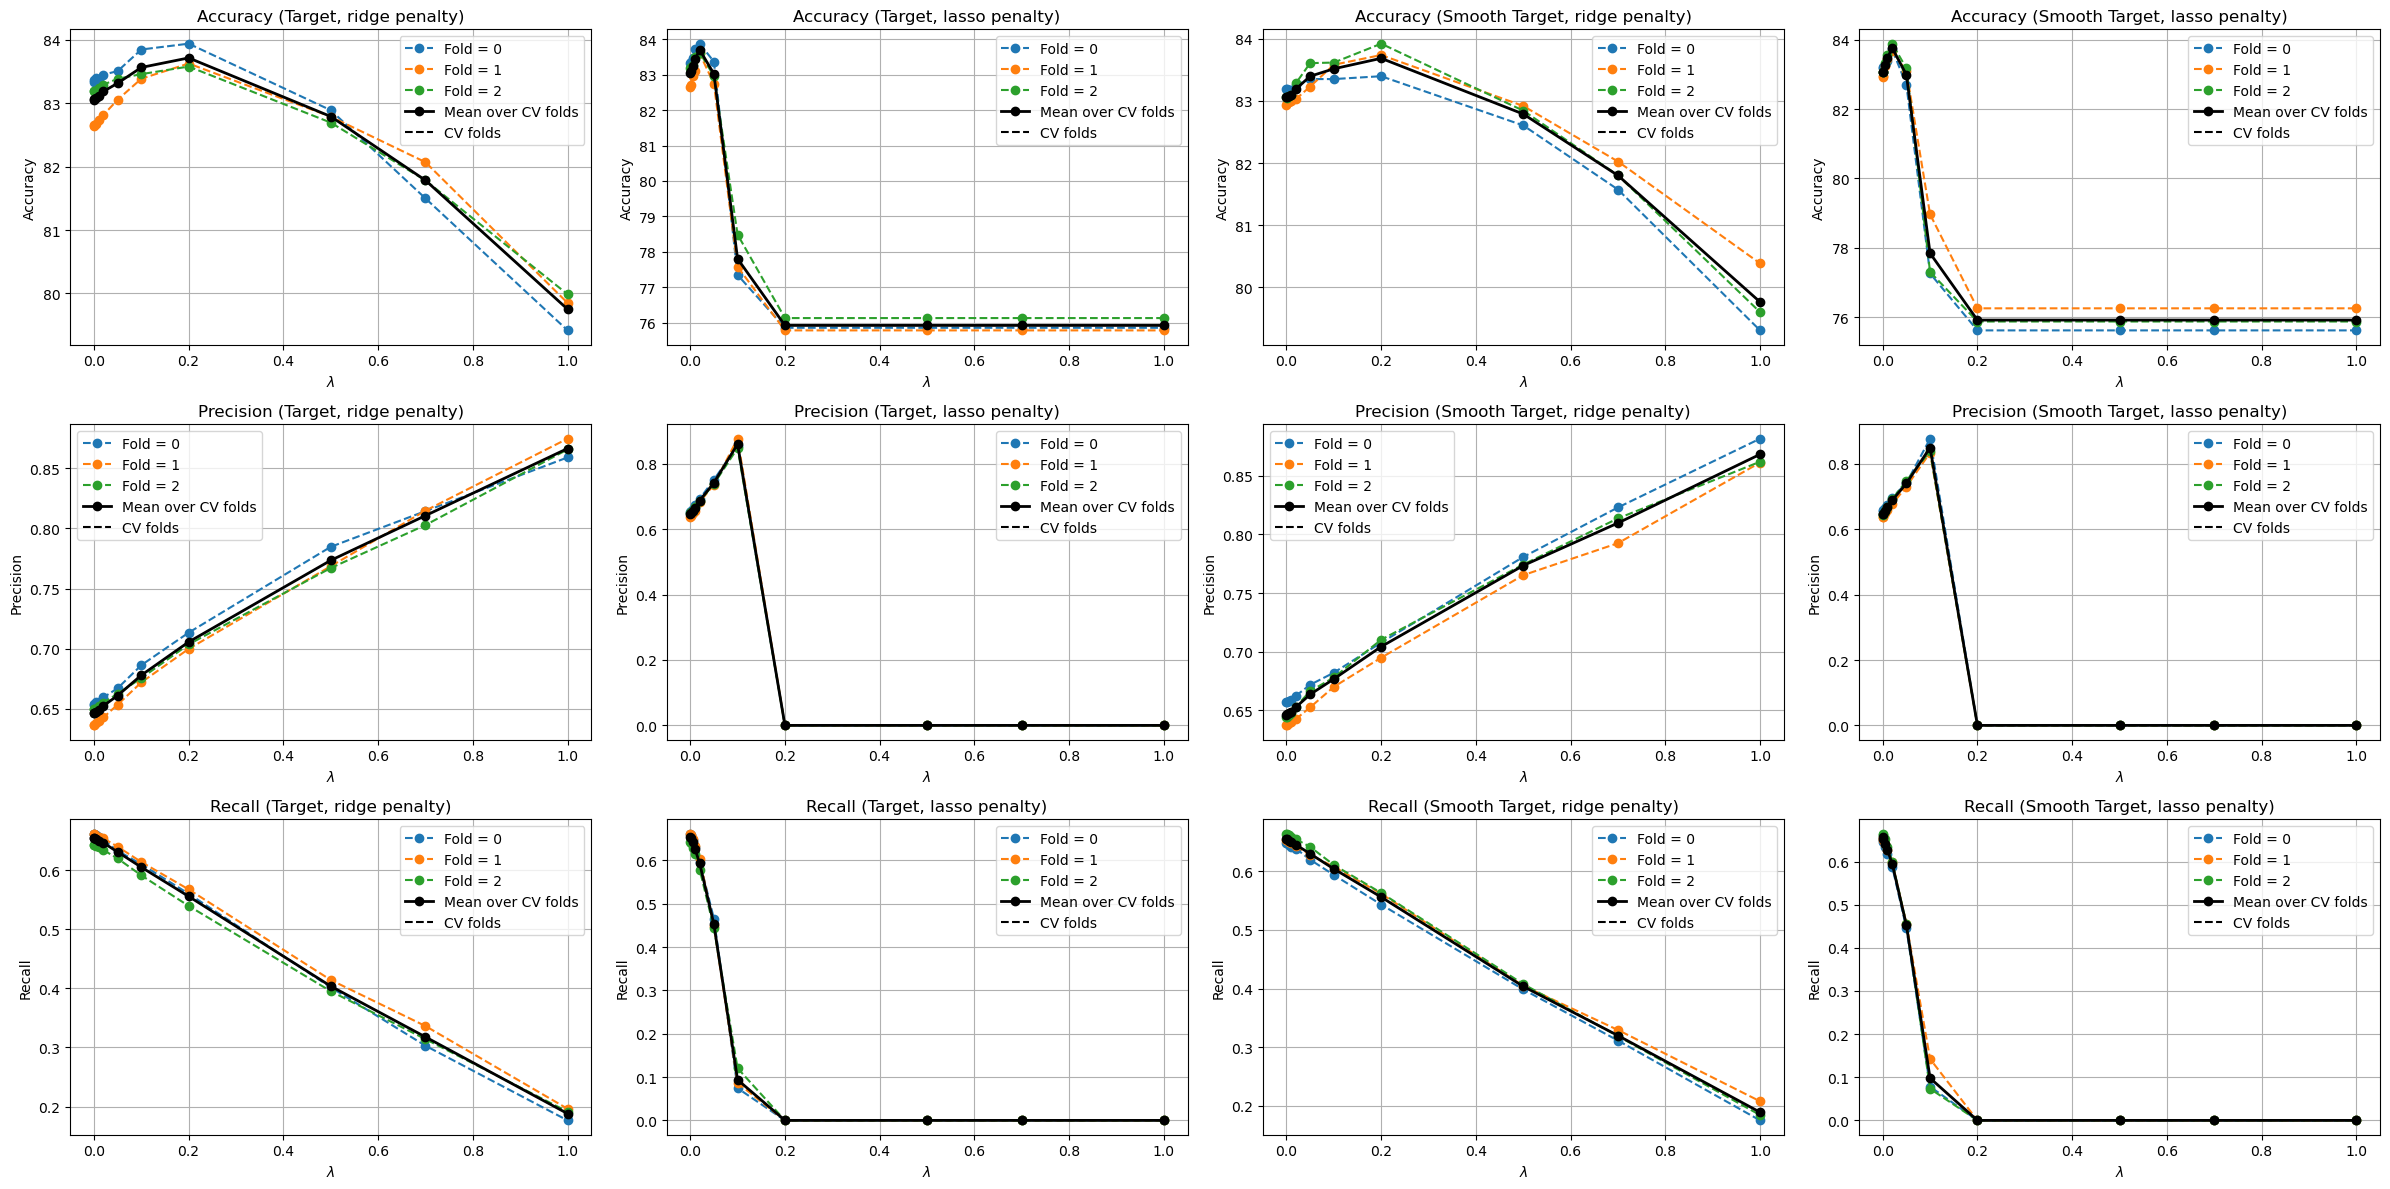

In [91]:
penalties_to_plot =["ridge","lasso"]
target_metric_data = [targ_acc_by_fold, targ_prec_by_fold, targ_rec_by_fold]
smooth_metric_data = [smoo_acc_by_fold, smoo_prec_by_fold, smoo_rec_by_fold]
metric_names = ["Accuracy","Precision", "Recall"]

n_metrics = len(target_metric_data)
n_penalties = len(penalties_to_plot)

fig, axes = plt.subplots(n_metrics, 2*n_penalties, figsize=(6*(2*n_penalties), 4*n_metrics))


for row in range(n_metrics):
    
    for col in range(n_penalties):
        penalty = penalties_to_plot[col]
        ax = axes[row,col]
        
        for i  in range(len(target_metric_data[row][penalty])):
            ax.plot(lam,target_metric_data[row][penalty][i],ls='--', marker='o', label=f"Fold = {i}")
        
        mean_cv_metric = np.mean(np.array(target_metric_data[row][penalty]),axis=0)
        ax.plot(lam,mean_cv_metric, color='k', linewidth=2, marker='o', label='Mean over CV folds')
        ax.plot([],[],ls='--',color='k', label='CV folds')
        
        ax.set_xlabel(r'$\lambda$')
        ax.set_ylabel(metric_names[row])
        ax.set_title(f'{metric_names[row]} (Target, {penalty} penalty)')
        ax.grid()
        ax.legend()
        
        best_l = lam[np.argmax(mean_cv_metric)]
        print(f"Best lambda value for {metric_names[row]} with Target Encoding and {penalty} penalty (CV estimate): {best_l}")
    
    for col in range(n_penalties):
        penalty = penalties_to_plot[col]
        ax = axes[row,col + n_penalties]
        
        for i in range(len(smooth_metric_data[row][penalty])):
            ax.plot(lam,smooth_metric_data[row][penalty][i],ls='--', marker='o', label=f"Fold = {i}")
        
        mean_cv_metric = np.mean(np.array(smooth_metric_data[row][penalty]),axis=0)
        ax.plot(lam,mean_cv_metric, color='k', linewidth=2, marker='o', label='Mean over CV folds')
        ax.plot([],[],ls='--',color='k', label='CV folds')
        
        ax.set_xlabel(r'$\lambda$')
        ax.set_ylabel(metric_names[row])
        ax.set_title(f'{metric_names[row]} (Smooth Target, {penalty} penalty)')
        ax.grid()
        ax.legend()
        
        best_l = lam[np.argmax(mean_cv_metric)]
        print(f"Best lambda value for {metric_names[row]} with Smooth Target Encoding and {penalty} penalty (CV estimate): {best_l}")

plt.tight_layout()

## 🚀 Analyze subgroup performance
In this part the following Requirements will be satisfied:

- Analyze subgroup performance (e.g., gender or race)

- Apply Lasso regression to compare sparsity across encodings

Here we will look at the subgroups with only On-Hot Encoding with lasso regression. The following precidure will be made:

- Only use Logistic Regression with an appropraite $\lambda$ and lasso regression
- We loop and train the model using ONLY the following columns respectivly:
>     ["sex"], ["race"], ["age_group", "sex"], ["education", "workclass"], ["marital-status", "relationship", "race"],
>     ["age_group", "hours_group", "education", >"sex", "native_country_group"]


In [92]:
###CODE

## Discussion


In this part the following Requirements will be satisfied:

- Why some features are better suited to non-one-hot encoding
- How encoding affects model interpretability (via coefficients)
- Tradeoffs between sparsity, performance, and leakage

### Why some features are better suited to non-one-hot encoding ✅

### How encoding affects model interpretability (via coefficients) ✅

### Tradeoffs between sparsity, performance, and leakage ✅